# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [3]:
#Variaveis de controle
num_anotados = 150

# **Pares Tweets-Reply**

In [4]:
# baixando dataset para o collab
import gdown

file_class_caio = "1G2jm-zH8rrL2O6aj03zgRIyI8d34dpgX"
file_class_victor = "1xEI0L_xmeMlyC5tD8_G_Sdj24TE0s99_"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "Contas_suspensas_caio.csv", quiet=False)
gdown.download(url_2, "Contas_suspensas_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1G2jm-zH8rrL2O6aj03zgRIyI8d34dpgX
To: /content/Contas_suspensas_caio.csv
100%|██████████| 459k/459k [00:00<00:00, 61.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xEI0L_xmeMlyC5tD8_G_Sdj24TE0s99_
To: /content/Contas_suspensas_victor.csv
100%|██████████| 459k/459k [00:00<00:00, 26.9MB/s]


'Contas_suspensas_victor.csv'

In [5]:
#carregando o dataset
df_caio = pd.read_csv ("Contas_suspensas_caio.csv")
df_victor = pd.read_csv ("Contas_suspensas_victor.csv")

In [6]:
#numero total de instancias no dataset
df_caio.shape

(1300, 7)

In [7]:
#numero total de instancias no dataset
df_victor.shape

(1300, 7)

In [8]:
df_caio.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,A absurda censura de contas nas redes sociais ...,"E tem gente que ainda acha que o ""Inquérito da...",2,0.597324,0.402676,0.0,Incerta
1,Menos Estado? Pros outros!..essa bela matéria ...,"Muitas vezes o discurso ""Estado mínimo"" signif...",2,0.480994,0.519006,0.0,Incerta
2,Censura nunca mais.,"O ódio pelo Bolsonaro, não pode ser maior que ...",1,0.480392,0.519608,0.0,Incerta
3,Hoje tivemos várias contas somente da direita ...,Vcs estão instaurando uma ditadura no país! Ce...,0,0.473109,0.526891,0.0,Incerta
4,Hoje é o dia da censura no Twitter?,Como sempre o senhor Alexandre de Moraes conti...,1,0.421183,0.578817,0.0,Incerta
5,"Estão cometendo crimes? Investigue, denuncie, ...",Vale lembrar que muitos estão com medidas caut...,2,0.549034,0.450966,1.0,Incerta
6,Vivemos em uma ditadura da toga #VozParaBernar...,Nossa Brasil virou uma Venezuela mordena e com...,2,0.521852,0.478148,0.0,Incerta
7,"A corrupção, no brasil, está ligada aos políti...",Deve ser a dinâmica do quanto pior pra nós mel...,2,0.439990,0.560010,0.0,Incerta
8,O dia em que a Corte guardiã da Constituição e...,24 de julho de 2020 vai entrar para a história...,2,0.553677,0.446323,0.0,Incerta
9,Opa peraí #VozParaBernardoKuster,"Gente, mentira que o Gado tá reclamando da ""ce...",0,0.596307,0.403693,1.0,Incerta


In [9]:
df_victor.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,A absurda censura de contas nas redes sociais ...,"E tem gente que ainda acha que o ""Inquérito da...",2,0.597324,0.402676,0.0,Incerta
1,Menos Estado? Pros outros!..essa bela matéria ...,"Muitas vezes o discurso ""Estado mínimo"" signif...",2,0.480994,0.519006,0.0,Incerta
2,Censura nunca mais.,"O ódio pelo Bolsonaro, não pode ser maior que ...",1,0.480392,0.519608,0.0,Incerta
3,Hoje tivemos várias contas somente da direita ...,Vcs estão instaurando uma ditadura no país! Ce...,0,0.473109,0.526891,0.0,Incerta
4,Hoje é o dia da censura no Twitter?,Como sempre o senhor Alexandre de Moraes conti...,1,0.421183,0.578817,0.0,Incerta
5,"Estão cometendo crimes? Investigue, denuncie, ...",Vale lembrar que muitos estão com medidas caut...,2,0.549034,0.450966,1.0,Incerta
6,Vivemos em uma ditadura da toga #VozParaBernar...,Nossa Brasil virou uma Venezuela mordena e com...,2,0.521852,0.478148,0.0,Incerta
7,"A corrupção, no brasil, está ligada aos políti...",Deve ser a dinâmica do quanto pior pra nós mel...,2,0.439990,0.560010,0.0,Incerta
8,O dia em que a Corte guardiã da Constituição e...,24 de julho de 2020 vai entrar para a história...,2,0.553677,0.446323,0.0,Incerta
9,Opa peraí #VozParaBernardoKuster,"Gente, mentira que o Gado tá reclamando da ""ce...",0,0.596307,0.403693,1.0,Incerta


In [10]:
df_remaining = df_caio.iloc[num_anotados:,:]
df_caio = df_caio.iloc[:num_anotados,:]
df_victor = df_victor.iloc[:num_anotados,:]

In [11]:
df_caio

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,A absurda censura de contas nas redes sociais ...,"E tem gente que ainda acha que o ""Inquérito da...",2,0.597324,0.402676,0.0,Incerta
1,Menos Estado? Pros outros!..essa bela matéria ...,"Muitas vezes o discurso ""Estado mínimo"" signif...",2,0.480994,0.519006,0.0,Incerta
2,Censura nunca mais.,"O ódio pelo Bolsonaro, não pode ser maior que ...",1,0.480392,0.519608,0.0,Incerta
3,Hoje tivemos várias contas somente da direita ...,Vcs estão instaurando uma ditadura no país! Ce...,0,0.473109,0.526891,0.0,Incerta
4,Hoje é o dia da censura no Twitter?,Como sempre o senhor Alexandre de Moraes conti...,1,0.421183,0.578817,0.0,Incerta
...,...,...,...,...,...,...,...
145,Mesmo que eu escreva um único parágrafo por di...,Gente que pedia AI-5 reclamando de censura kkk...,0,0.417370,0.582630,0.0,Incerta
146,Os outros ministros do STF não farão nada para...,vc não sabia que bandidos protegem bandidos.,2,0.599282,0.400718,0.0,Incerta
147,50 Rts e 30 Likes e eu posto sem censura,Sigam essa gostosa e deem muitos rts,2,0.483970,0.516029,0.0,Incerta
148,Como vc é tratado no Brasil qd é de direita e ...,Censura .. Mas só para a direita.. #FreedomOf...,2,0.482530,0.517470,0.0,Incerta


In [12]:
df_victor

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,A absurda censura de contas nas redes sociais ...,"E tem gente que ainda acha que o ""Inquérito da...",2,0.597324,0.402676,0.0,Incerta
1,Menos Estado? Pros outros!..essa bela matéria ...,"Muitas vezes o discurso ""Estado mínimo"" signif...",2,0.480994,0.519006,0.0,Incerta
2,Censura nunca mais.,"O ódio pelo Bolsonaro, não pode ser maior que ...",1,0.480392,0.519608,0.0,Incerta
3,Hoje tivemos várias contas somente da direita ...,Vcs estão instaurando uma ditadura no país! Ce...,0,0.473109,0.526891,0.0,Incerta
4,Hoje é o dia da censura no Twitter?,Como sempre o senhor Alexandre de Moraes conti...,1,0.421183,0.578817,0.0,Incerta
...,...,...,...,...,...,...,...
145,Mesmo que eu escreva um único parágrafo por di...,Gente que pedia AI-5 reclamando de censura kkk...,0,0.417370,0.582630,0.0,Incerta
146,Os outros ministros do STF não farão nada para...,vc não sabia que bandidos protegem bandidos.,2,0.599282,0.400718,0.0,Incerta
147,50 Rts e 30 Likes e eu posto sem censura,Sigam essa gostosa e deem muitos rts,2,0.483970,0.516029,0.0,Incerta
148,Como vc é tratado no Brasil qd é de direita e ...,Censura .. Mas só para a direita.. #FreedomOf...,2,0.482530,0.517470,-1.0,Incerta


In [13]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem

In [14]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [15]:
confusion

array([[106.,   8.,   3.],
       [  4.,  26.,   0.],
       [  1.,   1.,   1.]])

In [16]:
idx_diff

[10, 13, 26, 42, 48, 53, 57, 74, 87, 95, 112, 115, 136, 140, 142, 148, 149]

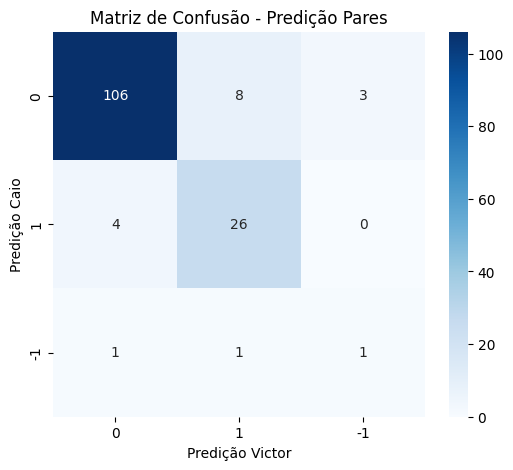

In [17]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares")
plt.show()

In [18]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff)):
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tweet 1:  Meu pai será reeleito em 1° turno! Quem for votar nele, retweet  #Bolsonaro2022
Tweet 2:  Se vcs não fizerem nada contra a censura da toga, acho que infelizmente nosso PR não vai não.Sou Brasileiro não desisto nunca, acho que o Alexandre de Moraes tá jantando vcs.
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  Muitos confundem apoio com devoção!  A medida q ele tá "abandonado" as pautas conservadoras e os seguidores mais aguerridos, as notícias da grande mídia começam a ficar mais favoráveis e as pesquisas mostram aumento da sua popularidade, mas isso é traição, novos Nandos Moura...
Tweet 2:  Acho debativel. Mas sobre a grande mídia, eu n sei do q você tá falando n. Até onde eu vejo, tá igual, se não pior.
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  EU vendo que contas bolsonaristas são retiradas do ar no Twitter e Facebook e que o pessoal que pede a volta da ditadura tá reclamando de censura
Tweet 2:  e   vcs sã

# **Criando Dataset das divergencias**

In [19]:
div_contas_suspensas = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div_contas_suspensas['Conflict_caio'] = df_caio['Conflict'].iloc[idx_diff].astype(int)
div_contas_suspensas['Conflict_victor'] = df_victor['Conflict'].iloc[idx_diff].astype(int)
div_contas_suspensas['Conflict'] = np.nan

In [20]:
div_contas_suspensas.shape

(17, 9)

In [21]:
div_contas_suspensas_final = div_contas_suspensas.drop(columns=['Conflict_caio', 'Conflict_victor'])
div_contas_suspensas_final

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Tipo,Conflict
10,Meu pai será reeleito em 1° turno! Quem for vo...,Se vcs não fizerem nada contra a censura da to...,2,0.482863,0.517137,Incerta,NaN
13,Muitos confundem apoio com devoção! A medida ...,"Acho debativel. Mas sobre a grande mídia, eu n...",1,0.424461,0.575539,Incerta,NaN
26,EU vendo que contas bolsonaristas são retirada...,e vcs são uns ícones,2,0.477281,0.522719,Incerta,NaN
42,Censura é só quando derrubam quem concorda com...,será que a CNN está tratando com normalidade a...,0,0.475937,0.524063,Incerta,NaN
48,Coloquei a postagem do discurso da deputada Be...,Sou contra a censura também. Mas em caso de us...,1,0.546233,0.453767,Incerta,NaN
53,Opiniões e críticas podem ser criminosas. É ób...,A censura prévia é impedir que alguém se manif...,1,0.113497,0.886503,Alta,NaN
57,"Proibir, com ordem prévia e geral, que uma pes...",Em ditadura não existe censura,1,0.104259,0.895741,Alta,NaN
74,Para ameaça ja tem lei no código penal.. Ofens...,Não falei de censurar ameaça. Só estou dizendo...,1,0.136441,0.863559,Alta,NaN
87,Exclusivo: Luciano Hang obteve 55 empréstimos ...,Mas nossa esse estadão malvadão existem pra al...,2,0.986925,0.013075,Random,NaN
95,bom dia mas só pra quem também é uma grande me...,Saber que Bolsonaro é preferência nacional pel...,0,0.983973,0.016027,Random,NaN


In [22]:
div_contas_suspensas_final.to_csv("divergencias_contas_suspensas_exploratoria.csv", index=False, encoding="utf-8")
files.download("divergencias_contas_suspensas_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**




In [23]:
conv_contas_suspensas = df_caio.drop(index=idx_diff, errors='ignore')

In [24]:
conv_contas_suspensas.shape

(133, 7)

In [25]:
conv_contas_suspensas

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,A absurda censura de contas nas redes sociais ...,"E tem gente que ainda acha que o ""Inquérito da...",2,0.597324,0.402676,0.0,Incerta
1,Menos Estado? Pros outros!..essa bela matéria ...,"Muitas vezes o discurso ""Estado mínimo"" signif...",2,0.480994,0.519006,0.0,Incerta
2,Censura nunca mais.,"O ódio pelo Bolsonaro, não pode ser maior que ...",1,0.480392,0.519608,0.0,Incerta
3,Hoje tivemos várias contas somente da direita ...,Vcs estão instaurando uma ditadura no país! Ce...,0,0.473109,0.526891,0.0,Incerta
4,Hoje é o dia da censura no Twitter?,Como sempre o senhor Alexandre de Moraes conti...,1,0.421183,0.578817,0.0,Incerta
...,...,...,...,...,...,...,...
143,Não há liberdade de expressão quando não podem...,Liberdade sempre foi o bem mais precioso para ...,2,0.562574,0.437426,0.0,Incerta
144,Não há como aceitar a censura. Não há como ace...,Contra essa censura de liberdade já estamos pr...,1,0.519535,0.480465,0.0,Incerta
145,Mesmo que eu escreva um único parágrafo por di...,Gente que pedia AI-5 reclamando de censura kkk...,0,0.417370,0.582630,0.0,Incerta
146,Os outros ministros do STF não farão nada para...,vc não sabia que bandidos protegem bandidos.,2,0.599282,0.400718,0.0,Incerta


In [26]:
#adicionando as classificações do professor
#file_class_contas_suspensas_prof = "1FSUrpSaiBAp5Gho-CsEw6kse3q4wCB8B"
#url = f"https://drive.google.com/uc?id={file_class_aborto_prof}"
#gdown.download(url, "contas_suspensas_class_prof.csv", quiet=False)
#df_class_prof = pd.read_csv ("contas_suspensas_class_prof.csv")

In [27]:
#df_class_prof

In [28]:
#df_desempate = div_aborto.merge(df_class_prof, on=['tweet_1', 'tweet_2'], how='inner')
#df_desempate = df_desempate.drop(columns=['Conflict_x', 'Class_y'])
#df_desempate = df_desempate.rename(columns={'Class_x': 'Class', 'Conflict_y': 'Conflict_prof'})
#df_desempate

In [29]:
def resolver_conflito(row):
    prof = row['Conflict_prof']
    caio = row['Conflict_caio']
    victor = row['Conflict_victor']

    if prof == caio or prof == victor:
        return prof
    else:
        return -1

#df_desempate['Conflict'] = df_desempate.apply(resolver_conflito, axis=1)

In [30]:
#df_desempate

In [31]:
#df_desempate = df_desempate.drop(columns=['Conflict_caio', 'Conflict_victor', 'Conflict_prof'])
#df_desempate

In [32]:
#conv_contas_suspensas = pd.concat([conv_contas_suspensas, df_desempate], ignore_index=True, axis = 0)
#conv_contas_suspensas

In [33]:
conv_contas_suspensas.to_csv("convergencias_contas_suspensas_exploratoria.csv", index=False, encoding="utf-8")
files.download("convergencias_contas_suspensas_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Dataset com pares não anotados**

In [34]:
remainig_df = df_remaining.drop('Conflict', axis=1)
remainig_df

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Tipo
150,precisamos de ações afetivas contra a censura.,"Mas o governo Bolsonaro é assim, dia inteiro d...",0,0.110382,0.889618,Alta
151,"Sabem oq gente como os ""generais"" Luiz Ramos o...",Esse papo de que “a direita comemoraria se a e...,0,0.138569,0.861431,Alta
152,Não há liberdade de expressão quando não podem...,Primeiro vem a censura. Despois a tortura. E...,1,0.177845,0.822155,Alta
153,"Não é uma falácia, é um fato sobre a base do s...","Nao é um fato visto que ele não existe, é ape...",1,0.100328,0.899672,Alta
154,Amigos aqui é Roberto Jefferson. Entrei na con...,Você não está sozinho.,2,0.155188,0.844812,Alta
...,...,...,...,...,...,...
1295,Roberto Jeferson ( antes de sofrer a censura n...,Toda verdade,2,0.973463,0.026537,Random
1296,"Todo dia, ao acordar, Alexandre de Moraes pens...",Meu cocô tem mais importância que esse sujeito.,2,0.977919,0.022080,Random
1297,Várias contas foram retidas do Twitter sob a j...,apoiou quem é a favor de tortura e ditadura L...,2,0.074400,0.925600,Random
1298,Alexandre de Moraes precisa receber voz de pri...,Mas ele se acha o próprio Lampião.,2,0.871353,0.128647,Random


In [35]:
remainig_df.to_csv("contas_suspensas_nao_anotado_exploratoria.csv", index=False, encoding="utf-8")
files.download("contas_suspensas_nao_anotado_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>